# *RETAIL DATASET*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


In [2]:
# Load the dataset
df = pd.read_csv('retail_large_dataset.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year']  = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month

# Column lists used throughout the notebook
num_cols = ['age', 'product_price', 'quantity',
            'discount_percentage', 'final_price', 'delivery_days']
cat_cols = ['gender', 'customer_segment', 'product_category',
            'payment_method', 'shipping_type', 'return_status']

print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}")
df.head()

Rows: 100,000  |  Columns: 20


,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status,order_year,order_month
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No,2025,5
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes,2023,11
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No,2025,2
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No,2024,4
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No,2024,10


In [3]:
df.tail()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status,order_year,order_month
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No,2024,6
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No,2024,4
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No,2024,4
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No,2024,9
99999,C109999,19,Male,Kolkata,West Bengal,New,O149999,2025-11-15,Health,Supplements,37361,3,3,108720.51,Credit Card,Standard,2,No,2025,11


In [4]:
print("Shape       :", df.shape)
print("Missing vals:", df.isnull().sum().sum())
print("Duplicates  :", df.duplicated().sum())

Shape       : (100000, 20)
Missing vals: 0
Duplicates  : 0


# *UNIVARIATE ANALYSIS- One variable at a time. We look at its shape, spread, and frequency.*

In [5]:
df.describe().round(2)

,age,order_date,product_price,quantity,discount_percentage,final_price,delivery_days,order_year,order_month
count,100000.00,100000,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.56,2024-06-29 02:48:38.304000,30164.53,2.50,15.01,64165.72,5.51,2023.99,6.51
min,18.00,2023-01-01 00:00:00,500.00,1.00,0.00,357.00,1.00,2023.00,1.00
25%,30.00,2023-09-30 00:00:00,15375.00,1.00,7.00,24705.00,3.00,2023.00,4.00
50%,42.00,2024-06-28 00:00:00,30148.00,3.00,15.00,49752.39,5.00,2024.00,7.00
75%,54.00,2025-03-30 00:00:00,44957.00,4.00,23.00,94046.07,8.00,2025.00,10.00
max,65.00,2025-12-30 00:00:00,59998.00,4.00,30.00,239980.00,10.00,2025.00,12.00
std,13.85,NaN,17139.68,1.12,8.95,49969.28,2.87,0.82,3.46


Insight- The dataset consists of 100,000 complete observations with well-balanced distributions across most variables. The average age is 41.6 years (median 42), indicating a symmetric adult population. Product price has a mean of ₹30,164 with a wide range (₹500–₹59,998), while customers typically purchase 2–3 items (mean 2.5) with an average discount of 15%. The final price shows the most variation, with a mean of ₹64,166 and median of ₹49,752, indicating right skewness due to high-value transactions (max ~₹239,980). Delivery time is consistent at around 5–6 days, and orders are evenly distributed across 2023–2025 and months, suggesting stable demand over time.


Distribution of Age

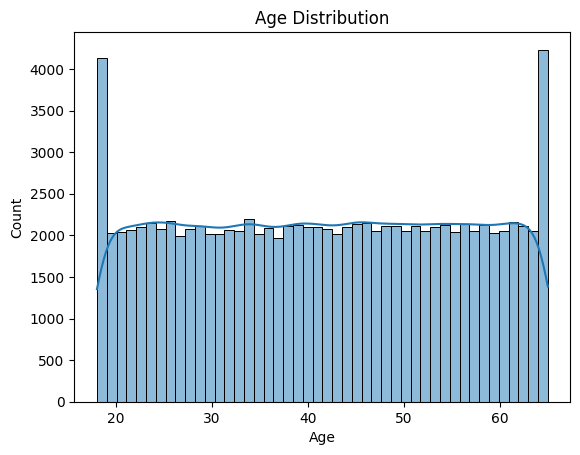

In [6]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Insight- The dataset represents a diverse customer base across all age groups, with no specific age segment dominating. However, the unusually high frequency at boundary ages (18 and 65) may indicate data recording constraints or preprocessing artifacts.

Pie Chart — Gender Distribution

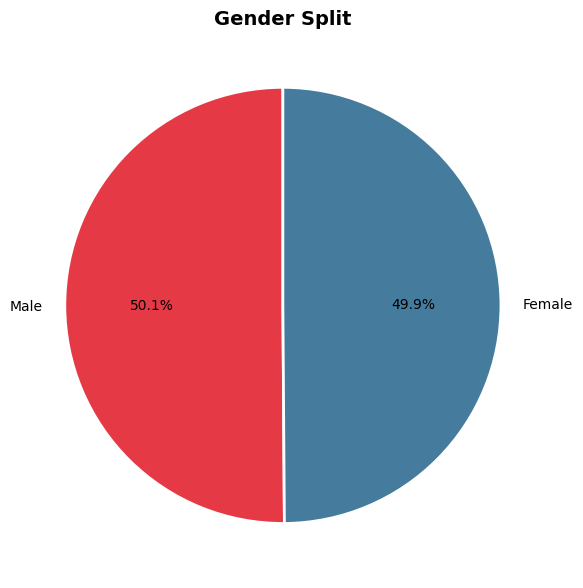

In [7]:
vc = df['gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(vc.values, labels=vc.index, colors=['#E63946','#457B9D'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
plt.title('Gender Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Insight- The customer base is evenly distributed between male and female users, indicating that the retail platform caters equally to both genders without any dominant segment.

Categorical — Product Category

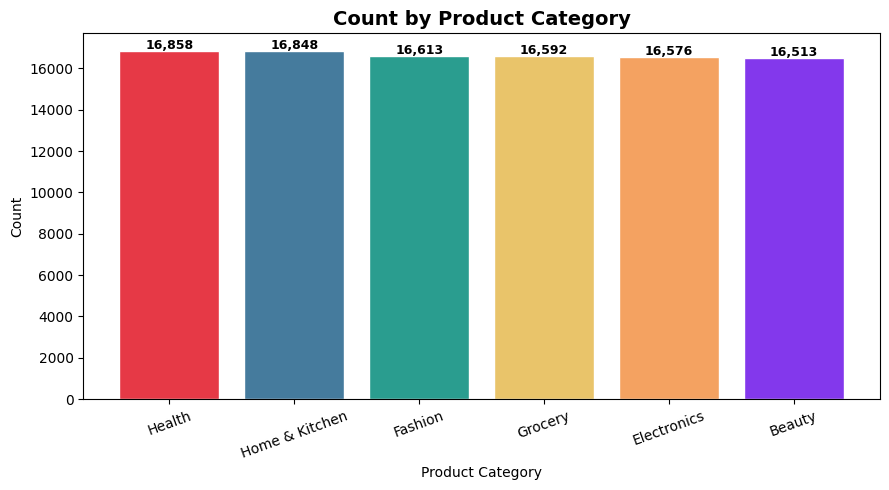

In [8]:
vc = df['product_category'].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(vc.index, vc.values,
               color=['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#8338EC'],
               edgecolor='white')
for bar, val in zip(bars, vc.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=9, fontweight='bold')
plt.title('Count by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Insight- The retail dataset maintains a uniform distribution across all product categories, suggesting that the platform offers a balanced inventory without over-representation of any specific category.

Categorical — Payment Method

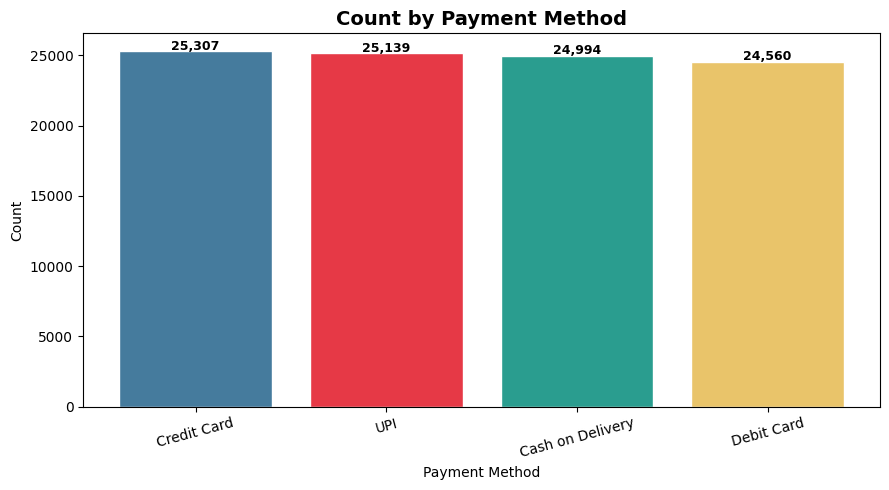

In [9]:
vc = df['payment_method'].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(vc.index, vc.values,
               color=['#457B9D','#E63946','#2A9D8F','#E9C46A'],
               edgecolor='white')
for bar, val in zip(bars, vc.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=9, fontweight='bold')
plt.title('Count by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Insight- Payment methods are uniformly distributed, with no dominant preference, indicating balanced adoption of digital and traditional payment options.

Categorical — Shipping Type

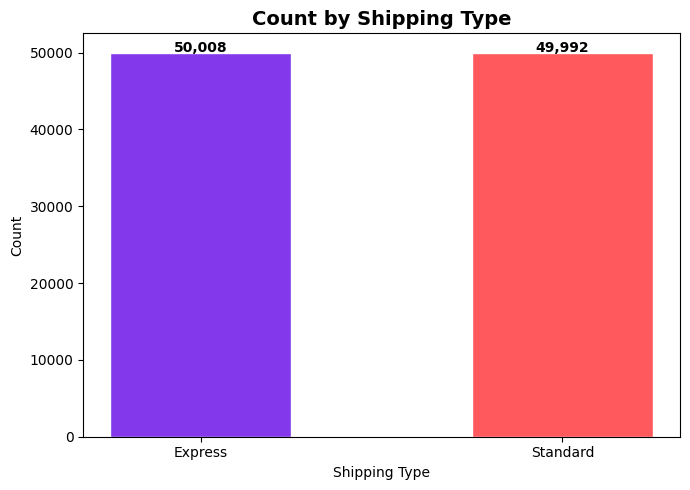

In [10]:
vc = df['shipping_type'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(vc.index, vc.values, color=['#8338EC','#FF595E','#FFCA3A'], edgecolor='white', width=0.5)
for bar, val in zip(bars, vc.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontweight='bold')
plt.title('Count by Shipping Type', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Categorical — Return Status

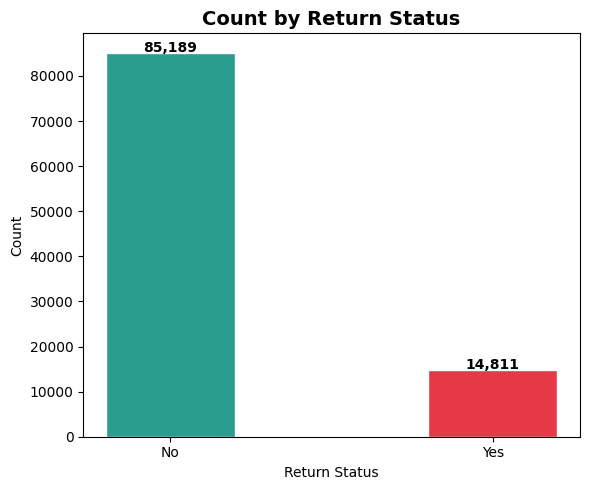

In [11]:
vc = df['return_status'].value_counts()

plt.figure(figsize=(6, 5))
bars = plt.bar(vc.index, vc.values, color=['#2A9D8F','#E63946'], edgecolor='white', width=0.4)
for bar, val in zip(bars, vc.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontweight='bold')
plt.title('Count by Return Status', fontsize=14, fontweight='bold')
plt.xlabel('Return Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Insight- The majority of transactions do not result in returns, indicating good product satisfaction or accurate product representation. However, a return rate of around 15% suggests there is still scope for improvement in product quality, customer expectations, or delivery experience.

Pie Chart — Customer Segment

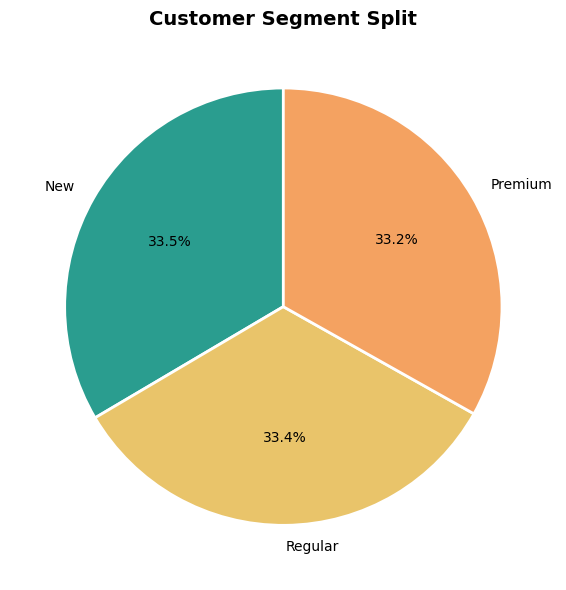

In [12]:
vc = df['customer_segment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(vc.values, labels=vc.index, colors=['#2A9D8F','#E9C46A','#F4A261'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
plt.title('Customer Segment Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Insight- Customer segments are uniformly distributed (~33% each), indicating a balanced mix of new, regular, and premium customers.

# *BIVARIATE ANALYSIS- Two variables at a time to check if they are related.*

Correlation Heatmap — All Numerical Columns

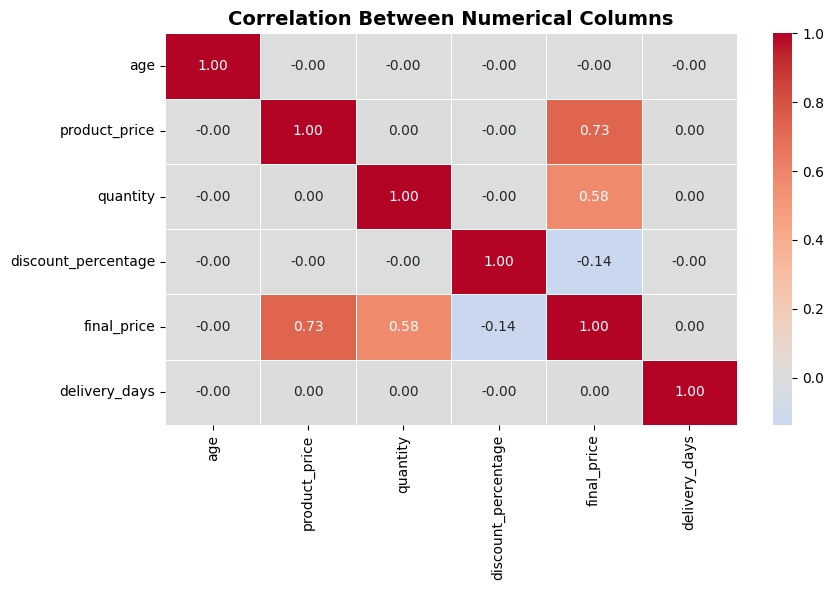

In [13]:
corr = df[num_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white')
plt.title('Correlation Between Numerical Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Insight- The analysis shows that final price is strongly influenced by product price and moderately by quantity, while discounts have only a minor impact. Customer demographics such as age and operational factors like delivery time do not significantly affect purchasing behavior or pricing.

Scatter — Product Price vs Final Price

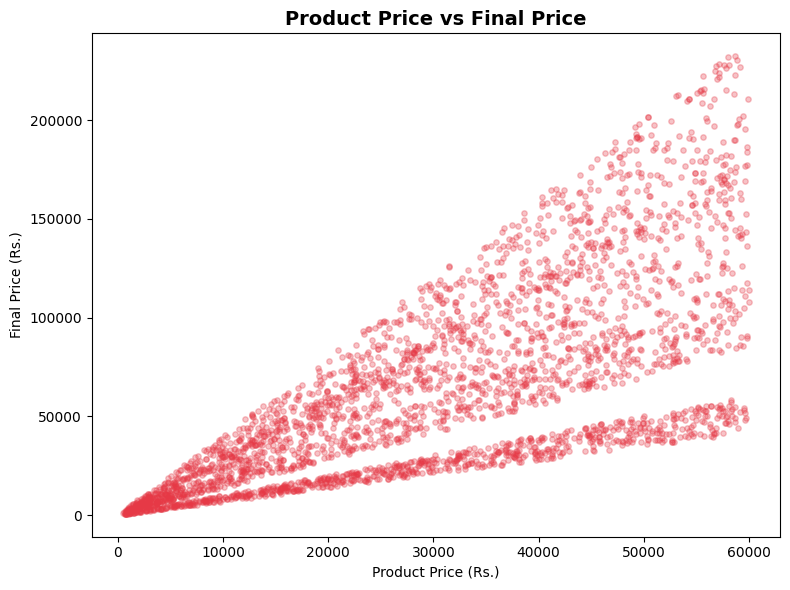

Correlation: 0.731


In [14]:
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample['product_price'], sample['final_price'],
            alpha=0.3, color='#E63946', s=15)
plt.title('Product Price vs Final Price', fontsize=14, fontweight='bold')
plt.xlabel('Product Price (Rs.)')
plt.ylabel('Final Price (Rs.)')
plt.tight_layout()
plt.show()

print(f"Correlation: {df['product_price'].corr(df['final_price']):.3f}")

Insight- The strong linear relationship confirms that final price is primarily driven by product price. However, the presence of multiple pricing bands suggests that different discount levels or purchase quantities influence the final transaction value. Additionally, higher-priced products exhibit greater variability, indicating more flexible pricing strategies for premium items.

Boxplot — Final Price by Product Category

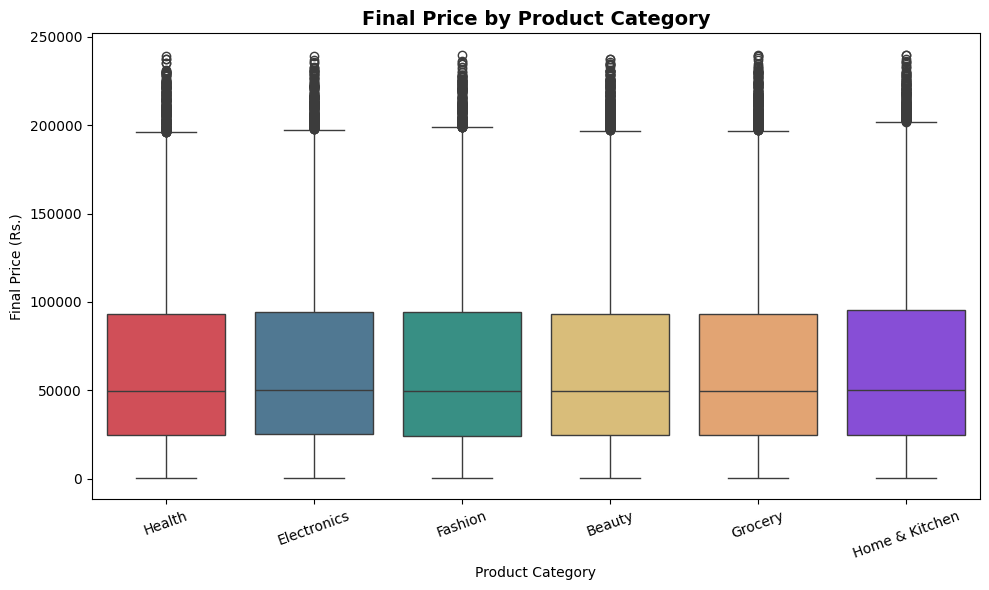

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='product_category', y='final_price',
            palette=['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#8338EC'])
plt.title('Final Price by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Final Price (Rs.)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Insight- The final price distribution is remarkably consistent across all product categories, with similar median values and variability. This suggests a balanced pricing strategy across categories. Significant outliers across all categories suggest the presence of high-value transactions, which should be handled carefully.

Boxplot — Delivery Days by Shipping Type

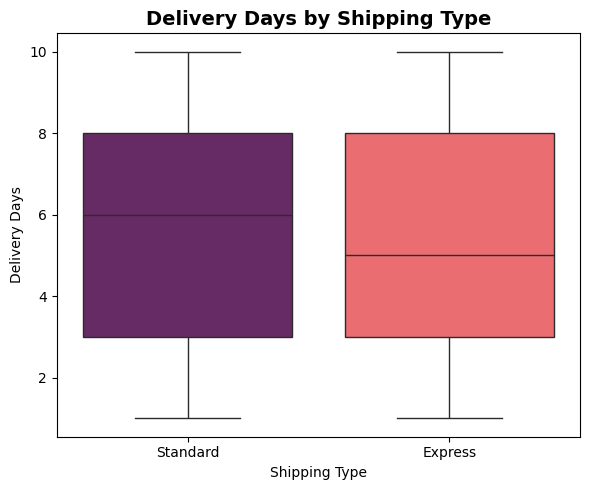

In [16]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='shipping_type', y='delivery_days',
            palette=["#70216D",'#FF595E','#FFCA3A'])
plt.title('Delivery Days by Shipping Type', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Type')
plt.ylabel('Delivery Days')
plt.tight_layout()
plt.show()

Insight- Although express shipping is expected to be significantly faster, the analysis shows only a marginal improvement over standard delivery. The large overlap in delivery times suggesting improvements in logistic systems.

In [17]:
CAT_COLORS = {
    'Beauty'        : '#E63946',
    'Electronics'   : '#457B9D',
    'Fashion'       : '#2A9D8F',
    'Grocery'       : '#E9C46A',
    'Health'        : '#F4A261',
    'Home & Kitchen': '#8338EC'
}

STATE_COLORS = {
    'Maharashtra' : '#E63946',
    'Telangana'   : '#457B9D',
    'Gujarat'     : '#2A9D8F',
    'Karnataka'   : '#E9C46A',
    'Tamil Nadu'  : '#F4A261',
    'Uttar Pradesh': '#8338EC',
    'Delhi'       : '#FF595E',
    'West Bengal' : '#FFCA3A',
    'Rajasthan'   : '#6A4C93'
}

STATE_PAL = list(STATE_COLORS.values())
SUB_PAL   = ['#E63946','#FF6B6B','#457B9D','#6BA4D8','#2A9D8F','#5EC4B8',
             '#E9C46A','#F7D98A','#F4A261','#F7C29A','#8338EC','#B07CF5',
             '#FF595E','#FFCA3A','#6A4C93','#1982C4','#8AC926','#FF924C',
             '#C77DFF','#48CAE4','#06D6A0']

print("Colour maps ready!")

Colour maps ready!


Count of Orders by State

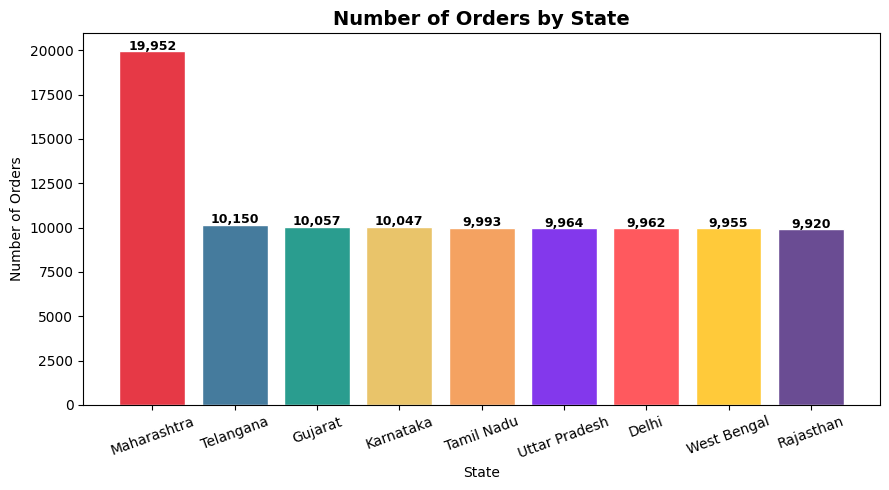

In [39]:
vc = df['state'].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(vc.index, vc.values, color=STATE_PAL[:len(vc)], edgecolor='white')
for bar, val in zip(bars, vc.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'{val:,}', ha='center', fontsize=9, fontweight='bold')
plt.title('Number of Orders by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Insight- Maharashtra emerges as the dominant market with nearly double the number of orders compared to other states, while the remaining states show a uniform distribution of orders, indicating consistent but moderate demand across regions. The sharp contrast between Maharashtra and other states suggests geographic concentration, highlighting both an opportunity for targeted expansion in other states and a risk of over-dependence on a single region.

Boxplot — Delivery Days by State

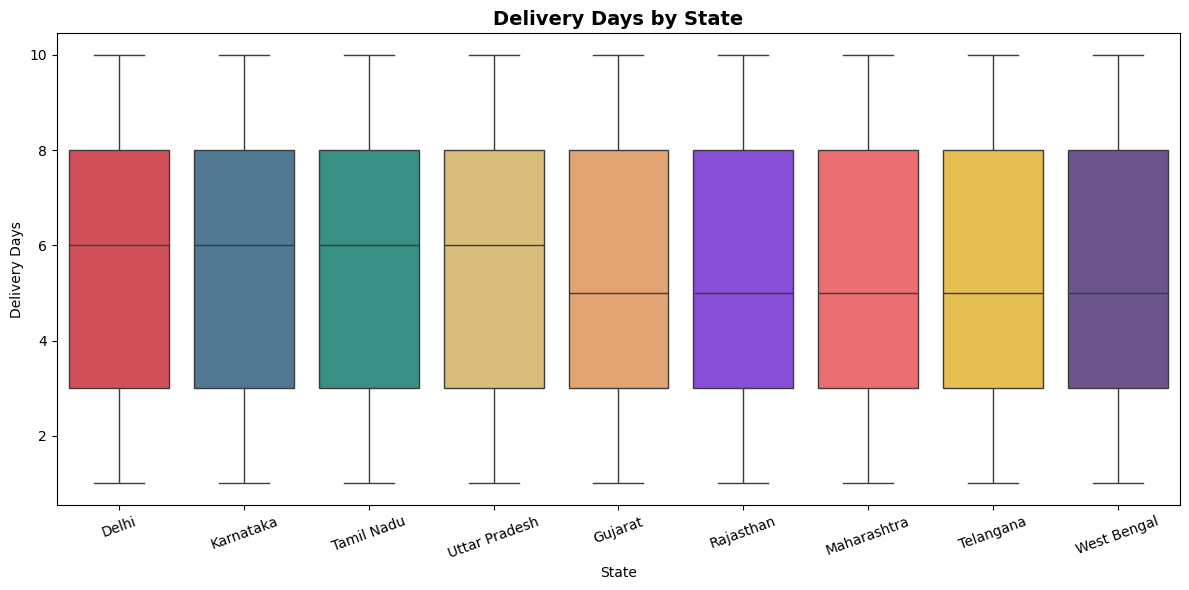

In [19]:
order = df.groupby('state')['delivery_days'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='state', y='delivery_days',
            order=order, palette=STATE_PAL[:len(order)])
plt.title('Delivery Days by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Delivery Days')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Insight- Delivery times are consistent across all states, with median values around 5–6 days and similar variability in each region. The distributions overlap significantly, indicating no meaningful difference in delivery performance between states. This suggests that logistics operations are standardized nationwide, ensuring uniform service quality regardless of location.


Line Chart — Monthly Order Trend

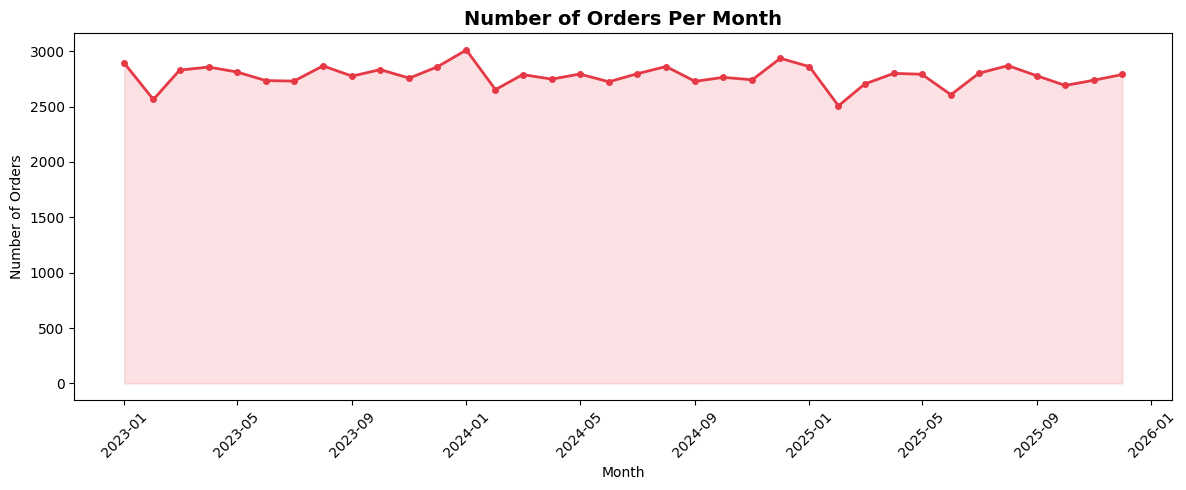

In [20]:
monthly = df.groupby(df['order_date'].dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, color='#E63946', linewidth=2, marker='o', markersize=4)
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color='#E63946')
plt.title('Number of Orders Per Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight- The number of orders per month remains relatively stable from January 2023 to late 2025, generally ranging between 2,600 and 3,000 orders. A peak is observed around January 2024 (~3000 orders), while slight dips occur around February 2023 and early 2025 (~2500–2600 orders). Overall, there is no strong upward or downward trend, indicating consistent demand with only minor monthly fluctuations.


Line Chart — Monthly Revenue by State

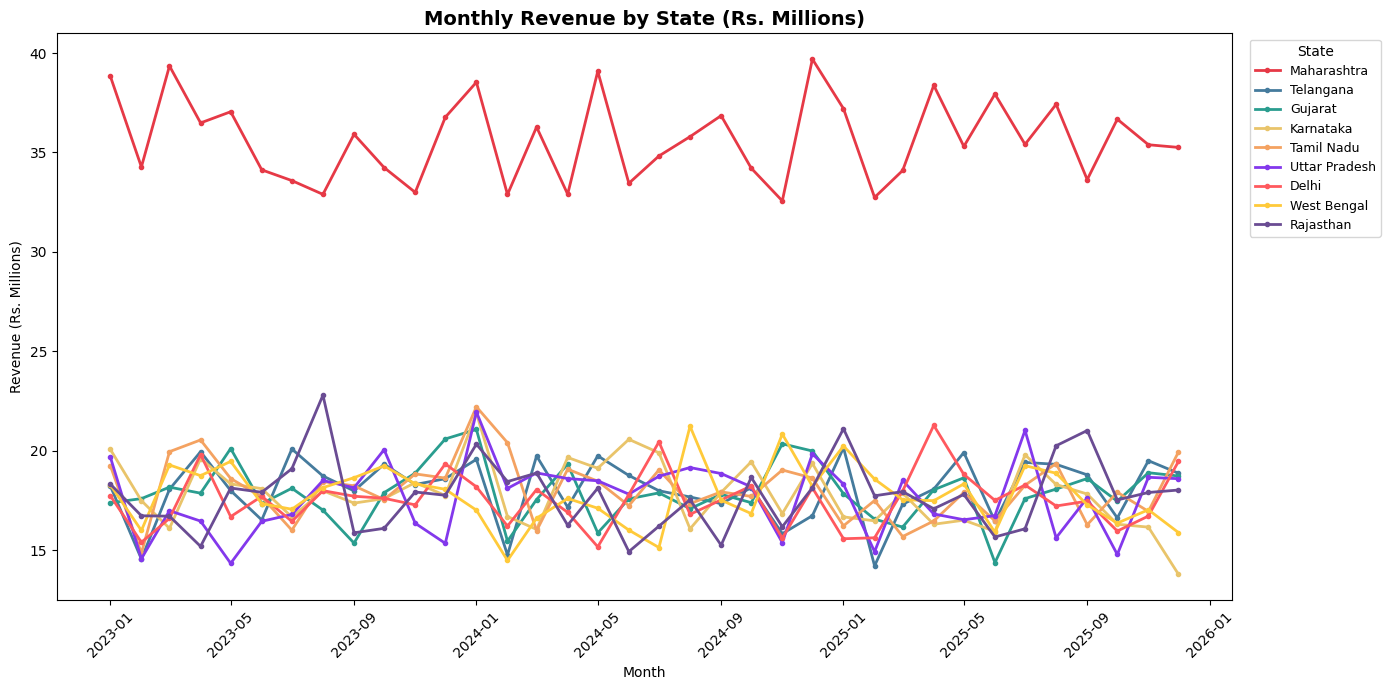

In [21]:
monthly_state = df.groupby([df['order_date'].dt.to_period('M'), 'state'])['final_price'].sum().unstack(fill_value=0) / 1e6
monthly_state.index = monthly_state.index.to_timestamp()

plt.figure(figsize=(14, 7))
for state, color in STATE_COLORS.items():
    if state in monthly_state.columns:
        plt.plot(monthly_state.index, monthly_state[state],
                 linewidth=2, marker='o', markersize=3,
                 label=state, color=color)
plt.title('Monthly Revenue by State (Rs. Millions)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs. Millions)')
plt.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight- Monthly revenue trends from January 2023 to late 2025 show that Maharashtra consistently leads, with revenues ranging around ₹33–40 million, peaking near late 2024 (~₹40M) and showing slight fluctuations throughout. In contrast, all other states such as Telangana, Gujarat, Karnataka, Tamil Nadu, Uttar Pradesh, Delhi, West Bengal, and Rajasthan maintain a relatively stable and similar range between ₹15–22 million, with minor month-to-month variations. Occasional peaks are observed across states (e.g., around early 2024 and early 2025), but no strong upward or downward trend is evident. Overall, the data highlights Maharashtra as the dominant revenue contributor, while other states exhibit consistent but moderate performance over time.


Grouped Bar — Product Category Popularity by State

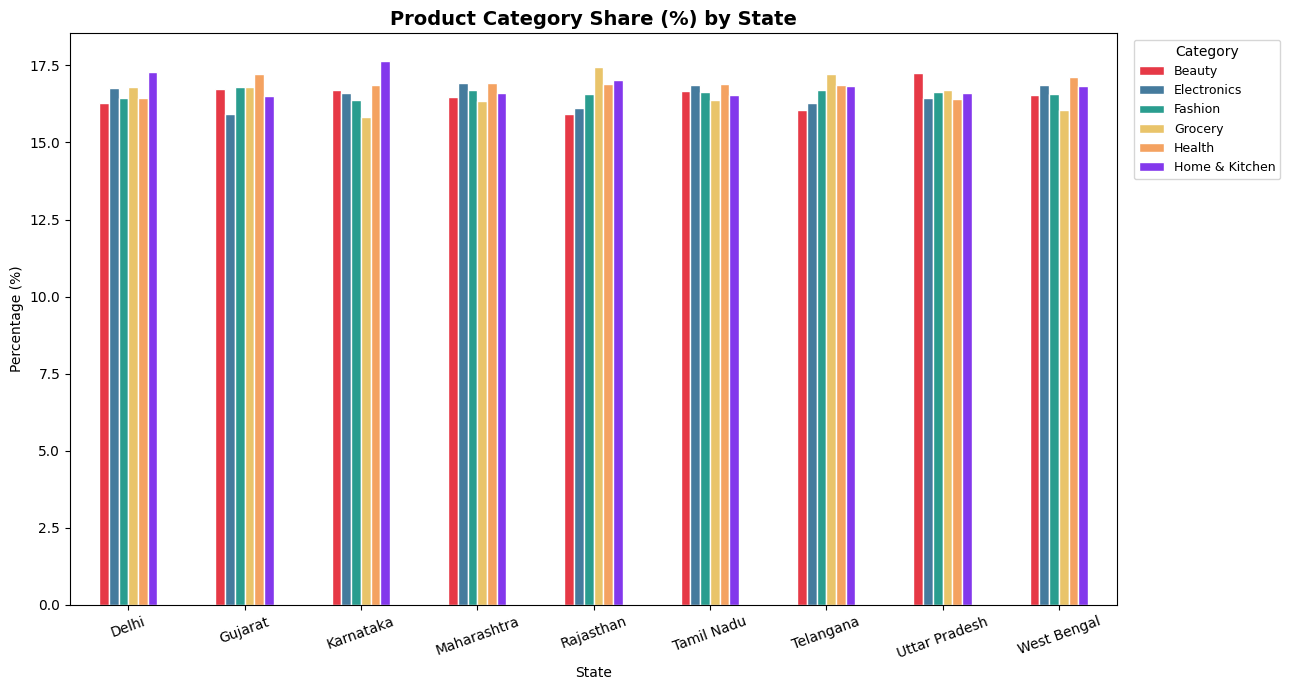

In [22]:
ct = pd.crosstab(df['state'], df['product_category'], normalize='index') * 100

ax = ct.plot(kind='bar', figsize=(13, 7),
             color=['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#8338EC'],
             edgecolor='white')
plt.title('Product Category Share (%) by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Insight- The product category share across states is highly uniform, with each category contributing roughly 16% to 18% in every state. No single category dominates in any region, and the variation between categories is minimal. For instance, categories like Home & Kitchen and Health are slightly higher in some states (e.g., Karnataka, Rajasthan), while Grocery or Electronics may be marginally lower, but the differences are not significant. Overall, this indicates a well-balanced product distribution across all states, suggesting consistent customer preferences and no strong regional bias toward any specific category.


Bar Chart — Payment Method by Customer Segment

<Figure size 900x600 with 0 Axes>

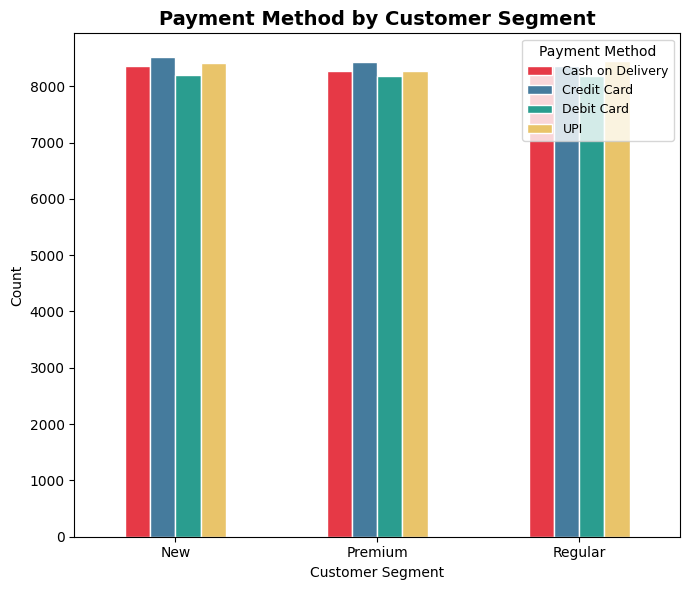

In [23]:
ct = pd.crosstab(df['customer_segment'], df['payment_method'])

plt.figure(figsize=(9, 6))
ct.plot(kind='bar', color=['#E63946','#457B9D','#2A9D8F','#E9C46A'],
        edgecolor='white', figsize=(7, 6))
plt.title('Payment Method by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Payment Method', fontsize=9)
plt.tight_layout()
plt.show()

Insight- The distribution of payment methods across customer segments (New, Premium, and Regular) is highly consistent, with all segments showing similar usage patterns. Credit Card and UPI are slightly more preferred across all segments, while Debit Card and Cash on Delivery are used marginally less, but the differences are minimal. No customer segment shows a distinct preference for a particular payment method, indicating that payment choice is independent of customer type. Overall, this suggests uniform adoption of payment options across all segments, with no significant behavioral variation.


# *MULTIVARIATE ANALYSIS- Three or more variables together.*

Heatmap — Avg Final Price by Category and Segment

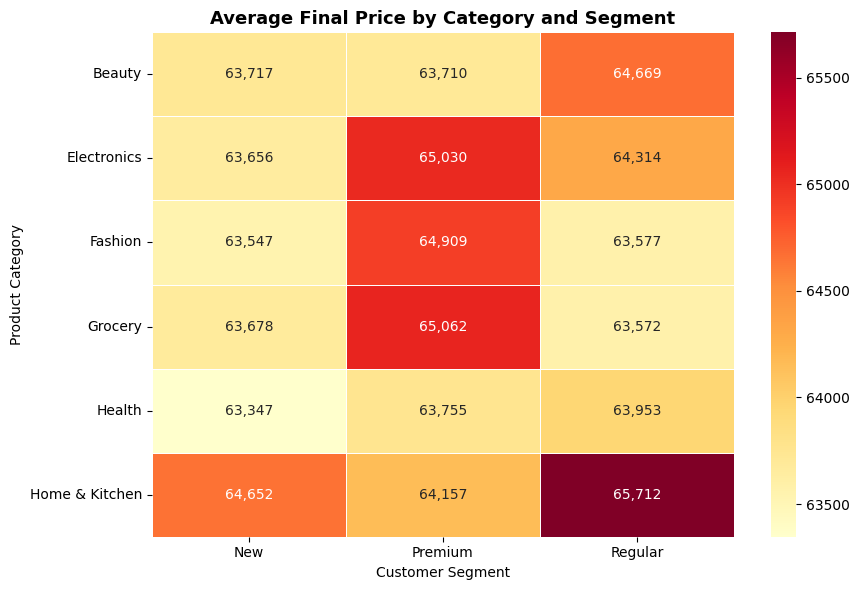

In [24]:
pivot = df.pivot_table(values='final_price',
                       index='product_category',
                       columns='customer_segment',
                       aggfunc='mean')

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Average Final Price by Category and Segment', fontsize=13, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

Insight- The average final price across product categories and customer segments shows minimal variation, generally ranging between ₹63,000 and ₹66,000. Premium customers tend to spend slightly more in categories like Electronics and Grocery (~₹65,000+), while Regular customers show higher spending in Home & Kitchen (~₹65,712). New customers have slightly lower or similar average spending across most categories. Overall, the differences across segments are small, indicating that customer segment has a limited impact on average spending, and pricing remains fairly consistent across categories.


Boxplot — Final Price by Category and Gender

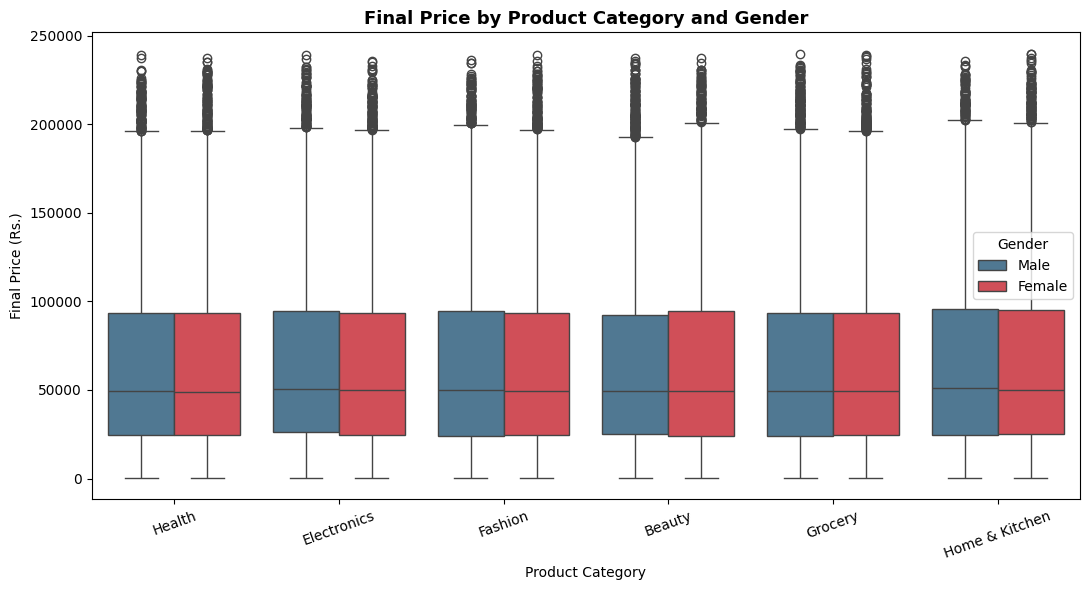

In [25]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x='product_category', y='final_price',
            hue='gender',
            palette={'Male':'#457B9D', 'Female':'#E63946'})
plt.title('Final Price by Product Category and Gender', fontsize=13, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Final Price (Rs.)')
plt.xticks(rotation=20)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

Insight- The distribution of final price across product categories and gender shows no significant difference between male and female customers. In all categories, both genders have nearly identical median values (around ₹45,000–₹50,000) and similar spreads, indicating comparable purchasing behavior. The presence of high-value outliers is consistent across both genders and all categories, suggesting that premium or bulk purchases are made equally by males and females. Overall, gender does not appear to influence spending patterns across any product category.

Boxplot — Final Price by Category and Segment

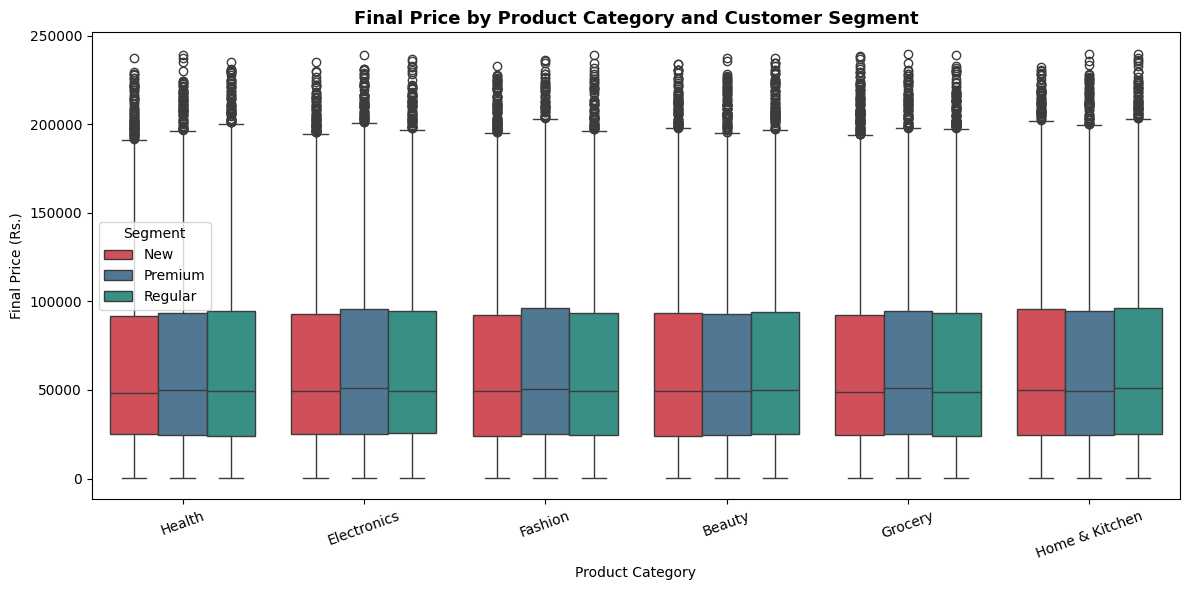

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='product_category', y='final_price',
            hue='customer_segment',
            palette={'New':'#E63946','Regular':'#2A9D8F','Premium':'#457B9D'})
plt.title('Final Price by Product Category and Customer Segment',
          fontsize=13, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Final Price (Rs.)')
plt.xticks(rotation=20)
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

Insight- The distribution of final price across product categories and customer segments (New, Premium, and Regular) shows very similar patterns across all groups. The median values for all segments lie around ₹45,000–₹50,000, with comparable spreads and ranges in each category. Although Premium customers show slightly higher medians in some categories, the differences are minimal and not significant. High-value outliers are present across all segments, indicating that premium or bulk purchases are made by all customer types. Overall, customer segment has little influence on spending behavior, and pricing patterns remain consistent across categories.


Stacked Bar — Revenue by Year and Category

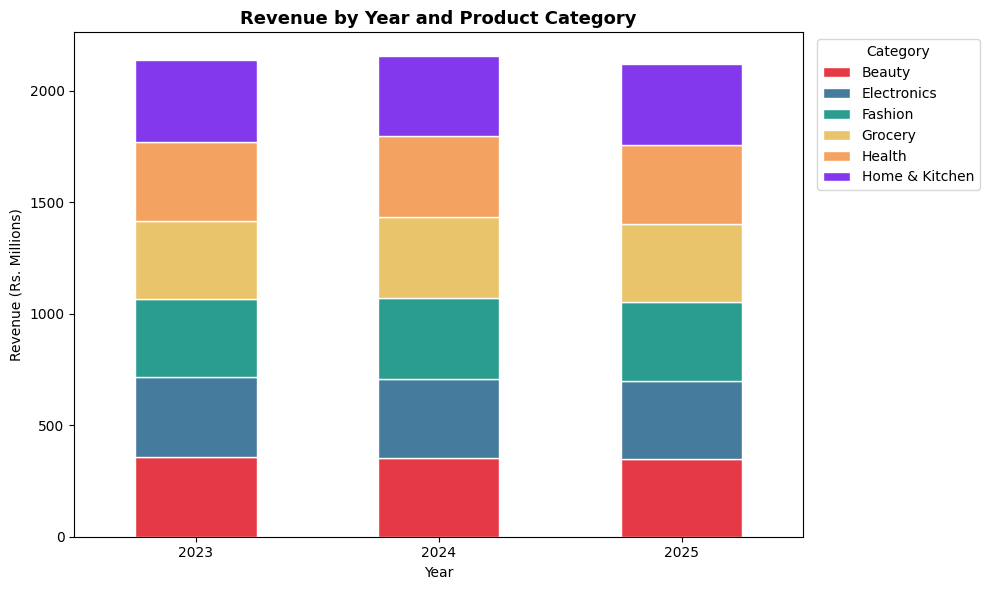

In [27]:
rev_pivot = df.pivot_table(values='final_price',
                           index='order_year',
                           columns='product_category',
                           aggfunc='sum') / 1e6

ax = rev_pivot.plot(kind='bar', stacked=True, figsize=(10, 6),
                    color=['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#8338EC'],
                    edgecolor='white')
plt.title('Revenue by Year and Product Category', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Revenue (Rs. Millions)')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight- The revenue by year and product category shows a consistent and balanced contribution from all categories across 2023, 2024, and 2025. Total revenue slightly increases in 2024 compared to 2023, followed by a small decline in 2025, but overall changes are minimal. Each category—Beauty, Electronics, Fashion, Grocery, Health, and Home & Kitchen—contributes almost equally every year, with no single category dominating. This indicates stable performance across categories and suggests that overall revenue trends are driven by collective consistency rather than category-specific growth or decline.


Scatter — State Avg Price vs Return Rate (bubble = revenue)

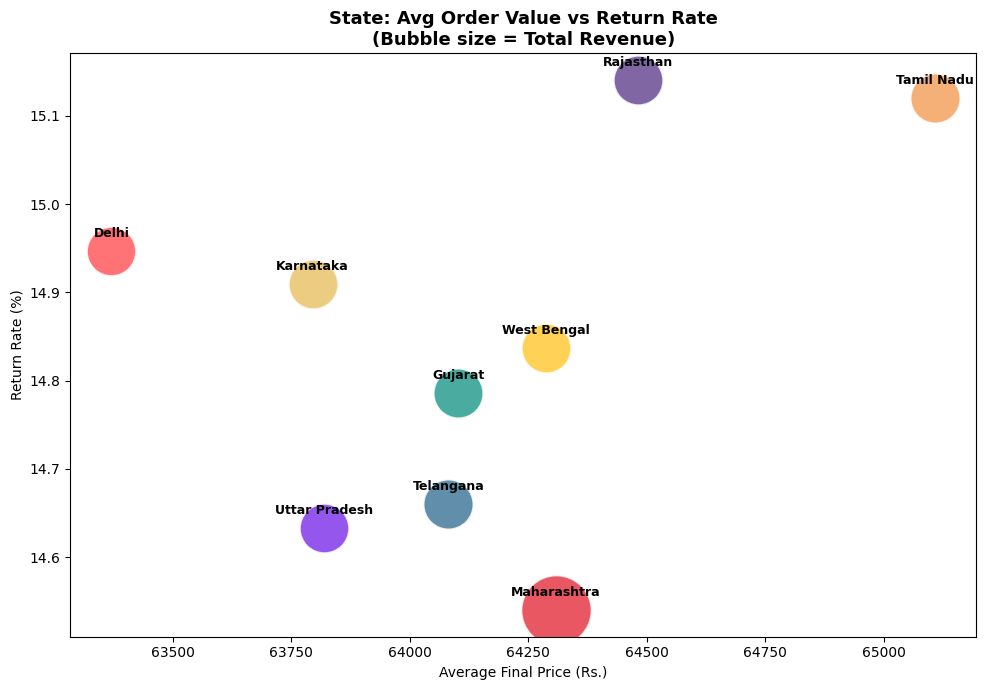

In [28]:
state_stats = df.groupby('state').agg(
    avg_price  = ('final_price', 'mean'),
    return_rate= ('return_status', lambda x: (x=='Yes').mean() * 100),
    total_rev  = ('final_price', 'sum')
).reset_index()

plt.figure(figsize=(10, 7))
for _, row in state_stats.iterrows():
    color = STATE_COLORS.get(row['state'], '#999999')
    plt.scatter(row['avg_price'], row['return_rate'],
                s=row['total_rev'] / 5e5,
                color=color, alpha=0.85, edgecolors='white', linewidth=1.5)
    plt.annotate(row['state'],
                 (row['avg_price'], row['return_rate']),
                 fontsize=9, ha='center', va='bottom',
                 xytext=(0, 8), textcoords='offset points', fontweight='bold')
plt.title('State: Avg Order Value vs Return Rate\n(Bubble size = Total Revenue)',
          fontsize=13, fontweight='bold')
plt.xlabel('Average Final Price (Rs.)')
plt.ylabel('Return Rate (%)')
plt.tight_layout()
plt.show()

Insight- The bubble chart shows that average order value and return rate are fairly similar across all states, with average prices ranging between ₹63,000 and ₹65,000 and return rates around 14.6% to 15.2%. Tamil Nadu has the highest average order value (~₹65,000+) with a slightly higher return rate, while Maharashtra shows a relatively high order value but the lowest return rate (~14.5%), indicating efficient performance. Rajasthan has one of the highest return rates (~15.2%) despite a moderate order value. The bubble sizes indicate that Maharashtra contributes the highest revenue, followed by other states with similar contributions. Overall, there is no strong relationship between order value and return rate, suggesting that returns are not directly driven by how much customers spend.


# *Outlier Detection and Treatment*


Outlier Summary Table

In [29]:
print(f"{'Column':<22} {'Q1':>8} {'Q3':>8} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>6}")
print("-" * 78)

for col in num_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n   = ((df[col] < lo) | (df[col] > hi)).sum()
    pct = n / len(df) * 100
    print(f"{col:<22} {q1:>8.1f} {q3:>8.1f} {lo:>10.1f} {hi:>10.1f} {n:>10,} {pct:>5.1f}%")

Column                       Q1       Q3      Lower      Upper   Outliers      %
------------------------------------------------------------------------------
age                        30.0     54.0       -6.0       90.0          0   0.0%
product_price           15375.0  44957.0   -28998.0    89330.0          0   0.0%
quantity                    1.0      4.0       -3.5        8.5          0   0.0%
discount_percentage         7.0     23.0      -17.0       47.0          0   0.0%
final_price             24705.0  94046.1   -79306.6   198057.7      1,335   1.3%
delivery_days               3.0      8.0       -4.5       15.5          0   0.0%


Insight- The outlier analysis using the IQR method shows that most variables do not contain significant outliers, as age, product price, quantity, discount percentage, and delivery days all have 0% outliers, indicating well-distributed and clean data. However, final price is the only variable with notable outliers, with 1,335 values (~1.3%) lying outside the acceptable range. This suggests the presence of high-value transactions or extreme purchases, which is common in retail datasets. Overall, the dataset is largely clean, but the outliers in final price should be handled carefully (e.g., capping or transformation) to avoid skewing analysis or modeling results.


Outlier Boxplot — Final Price

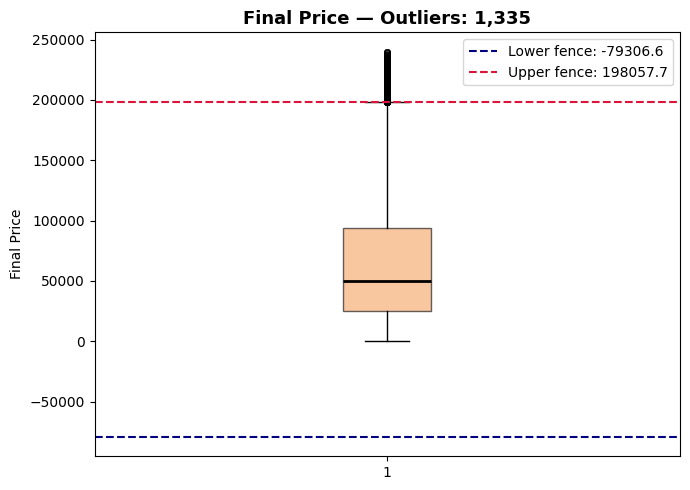

In [30]:
q1  = df['final_price'].quantile(0.25)
q3  = df['final_price'].quantile(0.75)
iqr = q3 - q1
lo  = q1 - 1.5 * iqr
hi  = q3 + 1.5 * iqr
n_out = ((df['final_price'] < lo) | (df['final_price'] > hi)).sum()

plt.figure(figsize=(7, 5))
plt.boxplot(df['final_price'], patch_artist=True,
            boxprops=dict(facecolor='#F4A261', alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', color='red', alpha=0.4, markersize=4))
plt.axhline(lo, color='navy',   linestyle='--', linewidth=1.5, label=f'Lower fence: {lo:.1f}')
plt.axhline(hi, color='crimson',linestyle='--', linewidth=1.5, label=f'Upper fence: {hi:.1f}')
plt.title(f'Final Price — Outliers: {n_out:,}', fontsize=13, fontweight='bold')
plt.ylabel('Final Price')
plt.legend()
plt.tight_layout()
plt.show()

Insight- The boxplot shows that final price has a significant number of upper-end outliers (1,335 cases), all lying above the upper fence (~₹198,058), while no lower outliers are present. The median is around ₹50,000, with most values concentrated between roughly ₹25,000 and ₹95,000, indicating a right-skewed distribution. The presence of many high-value points suggests premium or bulk transactions, which increase variability. These outliers are not necessarily errors but should be handled carefully (e.g., capping or log transformation) to prevent them from disproportionately influencing analysis.

Fix Outliers — Winsorisation (Capping)

In [31]:
# Winsorisation: cap values to the IQR fence instead of removing them
# Values below lower fence → replaced with lower fence
# Values above upper fence → replaced with upper fence

df_clean = df.copy()

print(f"{'Column':<22} {'Capped Low':>12} {'Capped High':>13}")
print("-" * 50)
for col in num_cols:
    q1  = df_clean[col].quantile(0.25)
    q3  = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_lo = (df_clean[col] < lo).sum()
    n_hi = (df_clean[col] > hi).sum()
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    print(f"{col:<22} {n_lo:>12,} {n_hi:>13,}")

print()
print("Done! Outliers have been capped. df_clean is the cleaned dataset.")

Column                   Capped Low   Capped High
--------------------------------------------------
age                               0             0
product_price                     0             0
quantity                          0             0
discount_percentage               0             0
final_price                       0         1,335
delivery_days                     0             0

Done! Outliers have been capped. df_clean is the cleaned dataset.


Insight- The outlier treatment results show that only the `final_price` variable required adjustment, with 1,335 high-end values capped, while all other variables remained unchanged. This confirms that extreme values were present only in the upper range of final price, consistent with earlier findings of right skewness and premium transactions. By capping these values, the dataset (`df_clean`) is now more stable and less influenced by extreme observations, improving the reliability of statistical analysis and modeling without removing important data points.


Before vs After — Final Price

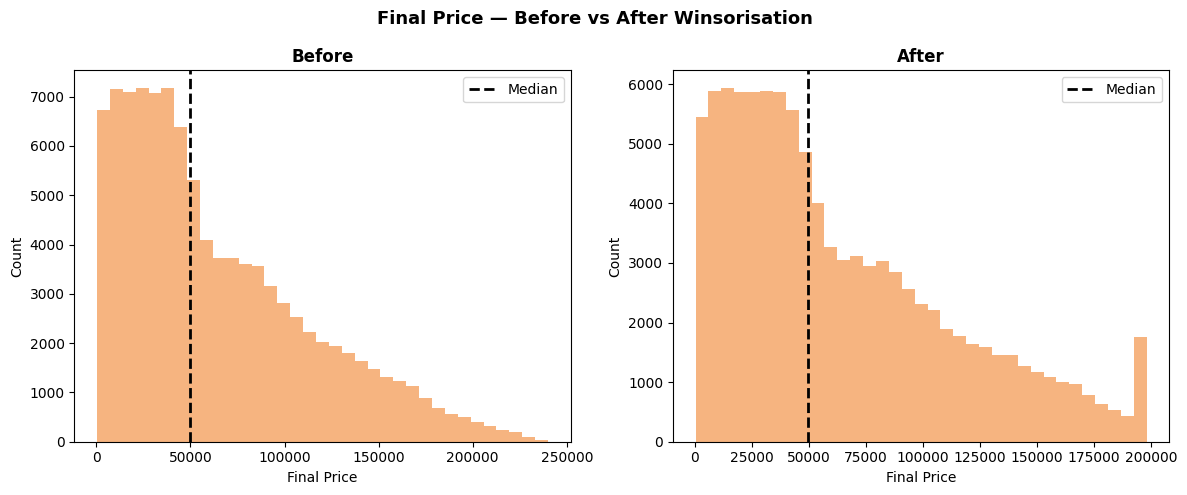

In [32]:
# Recreate df_clean if needed
if 'df_clean' not in dir():
    df_clean = df.copy()
    for c in num_cols:
        q1 = df_clean[c].quantile(0.25); q3 = df_clean[c].quantile(0.75)
        df_clean[c] = df_clean[c].clip(lower=q1-1.5*(q3-q1), upper=q3+1.5*(q3-q1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Final Price — Before vs After Winsorisation',
             fontsize=13, fontweight='bold')

axes[0].hist(df['final_price'],       bins=35, color='#F4A261', alpha=0.8, edgecolor='none')
axes[0].axvline(df['final_price'].median(), color='black', linestyle='--', linewidth=2, label='Median')
axes[0].set_title('Before', fontweight='bold')
axes[0].set_xlabel('Final Price')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df_clean['final_price'], bins=35, color='#F4A261', alpha=0.8, edgecolor='none')
axes[1].axvline(df_clean['final_price'].median(), color='black', linestyle='--', linewidth=2, label='Median')
axes[1].set_title('After', fontweight='bold')
axes[1].set_xlabel('Final Price')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

Insight- The comparison of final price before and after winsorisation shows that the original data was heavily right-skewed with a long tail of extreme high values, extending beyond ₹200,000. After winsorisation, these extreme values have been capped around ₹200,000, resulting in a more compact and controlled distribution. The overall shape remains right-skewed, but the influence of extreme outliers is reduced. Importantly, the median remains almost unchanged (~₹50,000), indicating that central tendency is preserved while variability is controlled. This confirms that winsorisation successfully stabilizes the dataset without distorting its core structure, making it more suitable for analysis.

# *Skewness and Kurtosis*

Skewness and Kurtosis — Summary Table

In [33]:
print(f"{'Column':<22} {'Skewness':>10}  {'Meaning':<26}  {'Kurtosis':>10}")
print("-" * 74)

for col in num_cols:
    s = df[col].skew()
    k = df[col].kurt()
    if   abs(s) < 0.5 : meaning = "Roughly Symmetric"
    elif s >  1        : meaning = "Highly Right Skewed"
    elif s < -1        : meaning = "Highly Left Skewed"
    elif s >  0.5      : meaning = "Moderately Right Skewed"
    else               : meaning = "Moderately Left Skewed"
    print(f"{col:<22} {s:>10.3f}  {meaning:<26}  {k:>10.3f}")

Column                   Skewness  Meaning                       Kurtosis
--------------------------------------------------------------------------
age                        -0.005  Roughly Symmetric               -1.201
product_price               0.003  Roughly Symmetric               -1.195
quantity                   -0.003  Roughly Symmetric               -1.365
discount_percentage        -0.004  Roughly Symmetric               -1.202
final_price                 0.935  Moderately Right Skewed          0.169
delivery_days               0.002  Roughly Symmetric               -1.222


Insight- The skewness and kurtosis analysis shows that most variables (age, product price, quantity, discount percentage, and delivery days) are approximately symmetric, with skewness values close to zero and negative kurtosis, indicating light-tailed (platykurtic) distributions with fewer extreme values. In contrast, final price stands out with a skewness of 0.935, indicating a moderate right skew, meaning higher-value transactions are more spread out. Its kurtosis is slightly positive (0.169), suggesting a distribution closer to normal but with some heavier tails compared to other variables. Overall, the dataset is well-behaved, with final price being the only variable showing noticeable skewness, which aligns with the presence of high-value transactions observed earlier.

Skewness Bar Chart

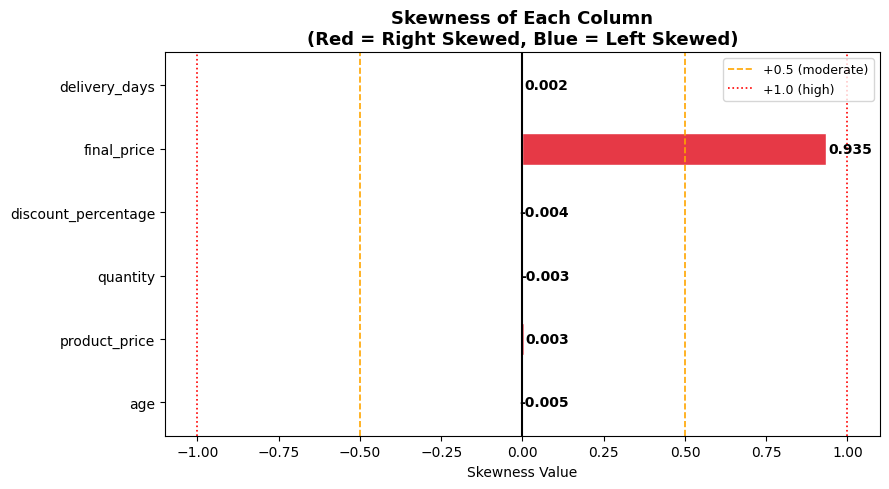

In [34]:
skew_vals = df[num_cols].skew()
bar_colors = ['#E63946' if v > 0 else '#457B9D' for v in skew_vals]

plt.figure(figsize=(9, 5))
bars = plt.barh(skew_vals.index, skew_vals.values,
                color=bar_colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, skew_vals.values):
    plt.text(val + 0.005 * (1 if val >= 0 else -1),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.axvline(0,    color='black',  linewidth=1.5)
plt.axvline( 0.5, color='orange', linewidth=1.2, linestyle='--', label='+0.5 (moderate)')
plt.axvline(-0.5, color='orange', linewidth=1.2, linestyle='--')
plt.axvline( 1.0, color='red',    linewidth=1.2, linestyle=':', label='+1.0 (high)')
plt.axvline(-1.0, color='red',    linewidth=1.2, linestyle=':')
plt.title('Skewness of Each Column\n(Red = Right Skewed, Blue = Left Skewed)',
          fontsize=13, fontweight='bold')
plt.xlabel('Skewness Value')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Insight- The skewness plot shows that almost all variables are centered around zero, indicating approximately symmetric distributions. Variables like age, product price, quantity, discount percentage, and delivery days have skewness values very close to zero, meaning there is no significant left or right skew. In contrast, final price stands out with a skewness of 0.935, indicating a moderate right skew, where higher values are more spread out due to premium or bulk transactions. Overall, the dataset is well-balanced, with final price being the only variable showing noticeable skewness, consistent with earlier observations of high-value outliers.

Kurtosis Bar Chart

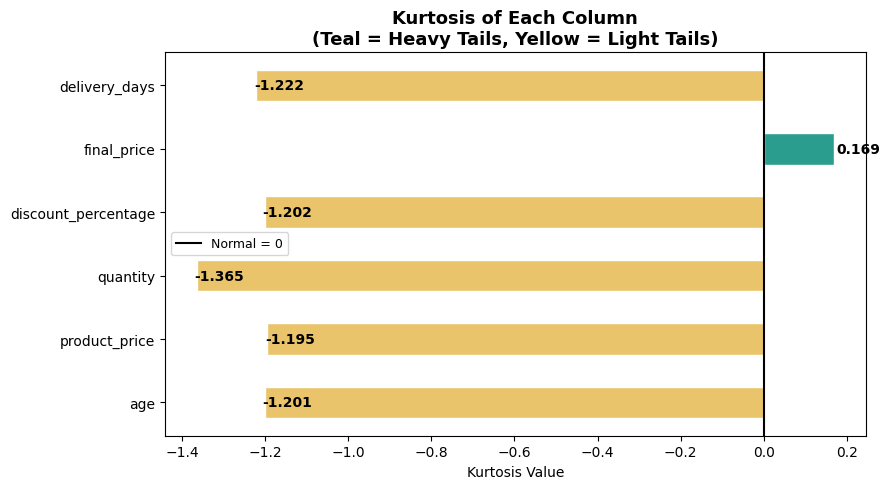

In [35]:
kurt_vals = df[num_cols].kurt()
bar_colors_k = ['#2A9D8F' if v > 0 else '#E9C46A' for v in kurt_vals]

plt.figure(figsize=(9, 5))
bars = plt.barh(kurt_vals.index, kurt_vals.values,
                color=bar_colors_k, edgecolor='white', height=0.5)
for bar, val in zip(bars, kurt_vals.values):
    plt.text(val + 0.005 * (1 if val >= 0 else -1),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.axvline(0, color='black', linewidth=1.5, label='Normal = 0')
plt.title('Kurtosis of Each Column\n(Teal = Heavy Tails, Yellow = Light Tails)',
          fontsize=13, fontweight='bold')
plt.xlabel('Kurtosis Value')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Insight- The kurtosis plot shows that most variables (age, product price, quantity, discount percentage, and delivery days) have negative kurtosis (~ -1.2), indicating light-tailed distributions with fewer extreme values and a flatter shape than normal. In contrast, final price has a slightly positive kurtosis (0.169), suggesting a distribution closer to normal but with mildly heavier tails, meaning a higher presence of extreme values. This aligns with earlier findings where final price showed outliers and right skewness. Overall, the dataset is well-behaved, with final price being the only variable exhibiting noticeable tail heaviness.


Skewness Histogram — Final Price

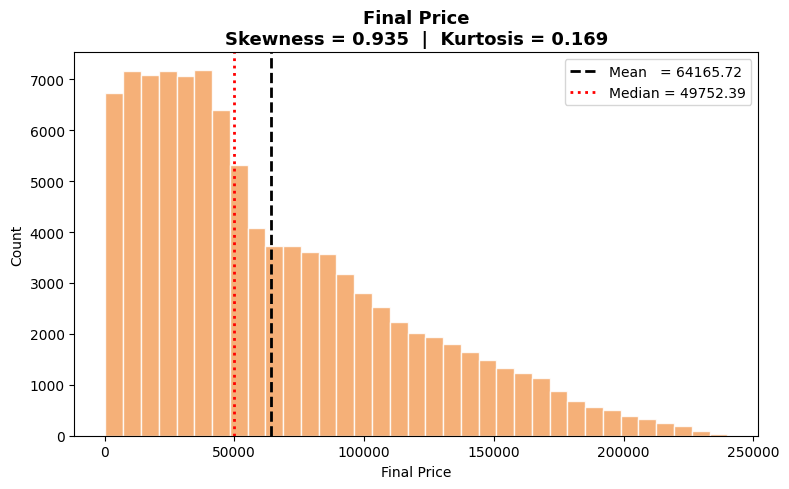

In [36]:
s = df['final_price'].skew()
k = df['final_price'].kurt()

plt.figure(figsize=(8, 5))
plt.hist(df['final_price'], bins=35, color='#F4A261', edgecolor='white', alpha=0.85)
plt.axvline(df['final_price'].mean(),   color='black', linestyle='--', linewidth=2, label=f'Mean   = {df["final_price"].mean():.2f}')
plt.axvline(df['final_price'].median(), color='red',   linestyle=':',  linewidth=2, label=f'Median = {df["final_price"].median():.2f}')
plt.title(f'Final Price\nSkewness = {s:.3f}  |  Kurtosis = {k:.3f}',
          fontsize=13, fontweight='bold')
plt.xlabel('Final Price')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

Insight- The distribution of final price is moderately right-skewed (skewness = 0.935), as seen by the long tail extending toward higher values. Most transactions are concentrated in the lower to mid range (around ₹20,000–₹80,000), while a smaller number of high-value purchases extend beyond ₹150,000. The mean (~₹64,166) is higher than the median (~₹49,752), further confirming right skewness due to these high-value transactions. The kurtosis (0.169) indicates a distribution close to normal but with slightly heavier tails. Overall, this suggests that while most customers make moderate purchases, a few high-value transactions significantly influence the distribution.

# *Summary*

In [37]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"Total rows          : {len(df):,}")
print(f"Total columns       : {len(df.columns)}")
print(f"Missing values      : {df.isnull().sum().sum()}")
print(f"Duplicate rows      : {df.duplicated().sum()}")
print()
print("Skewness & Kurtosis:")
print(f"  {'Column':<22} {'Skewness':>10} {'Kurtosis':>10}")
print("  " + "-" * 44)
for col in num_cols:
    print(f"  {col:<22} {df[col].skew():>10.3f} {df[col].kurt():>10.3f}")
print()
print("Outliers (IQR method):")
print(f"  {'Column':<22} {'Count':>8} {'%':>6}")
print("  " + "-" * 38)
for col in num_cols:
    q1  = df[col].quantile(0.25); q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n   = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    print(f"  {col:<22} {n:>8,} {n/len(df)*100:>5.1f}%")

EDA SUMMARY
Total rows          : 100,000
Total columns       : 20
Missing values      : 0
Duplicate rows      : 0

Skewness & Kurtosis:
  Column                   Skewness   Kurtosis
  --------------------------------------------
  age                        -0.005     -1.201
  product_price               0.003     -1.195
  quantity                   -0.003     -1.365
  discount_percentage        -0.004     -1.202
  final_price                 0.935      0.169
  delivery_days               0.002     -1.222

Outliers (IQR method):
  Column                    Count      %
  --------------------------------------
  age                           0   0.0%
  product_price                 0   0.0%
  quantity                      0   0.0%
  discount_percentage           0   0.0%
  final_price               1,335   1.3%
  delivery_days                 0   0.0%
